In [12]:
# Data setup

import json
import pandas as pd
import os

# Define paths
DATASET_PATH = "final_war_dataset_PERFECT.json"
IMAGE_DIR = "master_images"

# Load the merged JSON
if not os.path.exists(DATASET_PATH):
    print(f"❌ Error: {DATASET_PATH} not found!")
else:
    with open(DATASET_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Convert to DataFrame
    df = pd.DataFrame(data)

    # We check if 'content' or 'text' columns exist. 
    # If one is missing, we create it as empty so the merge doesn't crash.
    if 'content' not in df.columns:
        df['content'] = ""
    if 'text' not in df.columns:
        df['text'] = ""

    # Standardize text field: Use 'content' (News), fall back to 'text' (X)
    df['full_text'] = df['content'].fillna(df['text']).fillna("")
    
    # Also handle 'local_image' vs 'top_image' just in case
    if 'local_image' not in df.columns and 'top_image' in df.columns:
        df['local_image'] = df['top_image']
    elif 'local_image' not in df.columns:
         df['local_image'] = "N/A"

    print(f"✅ Loaded {len(df)} articles successfully.")
    print(f"Columns found: {list(df.columns)}")
    display(df.head(2))

✅ Loaded 1261 articles successfully.
Columns found: ['id', 'source', 'title', 'url', 'date', 'content', 'local_image', 'text', 'full_text']


,id,source,title,url,date,content,local_image,text,full_text
0,1,moneycontrol,"Economy News - Latest News on Indian Economy, ...",https://www.moneycontrol.com/news/business/eco...,N/A,"Middle East tensions a concern, but RBI likely...",war_data_2.png,,"Middle East tensions a concern, but RBI likely..."
1,2,moneycontrol,Iran FM Araghchi warns Bushehr nuclear plant s...,https://www.moneycontrol.com/world/iran-fm-ara...,2026-04-05 08:07:24+05:30,Russia — which has been involved in constructi...,war_data_24.jpg,,Russia — which has been involved in constructi...


In [13]:
# Auto labelling (VADER Sentiment Analysis)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_vader_label(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05: return 2   # Positive / High Alert
    if score <= -0.05: return 0  # Negative / Conflict
    return 1                     # Neutral

tqdm.pandas()
print("Labeling dataset...")
df['label'] = df['full_text'].progress_apply(get_vader_label)

# Save the labeled version
df.to_json("master_dataset_labeled.json", orient='records', indent=4)
print("Saved master_dataset_labeled.json")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\roypr\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Labeling dataset...


100%|█████████████████████████████████████████████████████████████████████████████| 1261/1261 [00:01<00:00, 708.72it/s]

Saved master_dataset_labeled.json


In [14]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers nltk pandas tqdm pillow

Looking in indexes: https://download.pytorch.org/whl/cu121


In [15]:
# Feature extraction (BERT + ResNet)

import torch
from transformers import BertTokenizer, BertModel
from torchvision import models, transforms
from PIL import Image

# Setup Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)

# ResNet for Images
resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()
# Remove the last classification layer to get 2048-dim features
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1]))

img_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

text_features = []
image_features = []
valid_labels = []

print(f"Extracting features using {device}...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_name = row['local_image']
    img_path = os.path.join(IMAGE_DIR, str(img_name))
    
    # Only process if image exists
    if img_name != "N/A" and os.path.exists(img_path):
        try:
            # 1. Image Features
            img = Image.open(img_path).convert('RGB')
            img_tensor = img_transforms(img).unsqueeze(0).to(device)
            with torch.no_grad():
                img_feat = resnet(img_tensor).flatten().cpu()
            
            # 2. Text Features (BERT)
            inputs = tokenizer(row['full_text'], return_tensors="pt", truncation=True, padding='max_length', max_length=128).to(device)
            with torch.no_grad():
                outputs = bert_model(**inputs)
                text_feat = outputs.pooler_output.squeeze().cpu()
            
            image_features.append(img_feat)
            text_features.append(text_feat)
            valid_labels.append(row['label'])
        except Exception as e:
            continue

# Save as Tensors
torch.save({
    'text': torch.stack(text_features),
    'image': torch.stack(image_features),
    'labels': torch.tensor(valid_labels)
}, 'features.pt')

print(f"Extracted features for {len(valid_labels)} multimodal pairs.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\roypr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\roypr\anaconda3\Lib\site-packages\torchvisi

Extracting features using cuda...


  0%|                                                                                         | 0/1261 [00:00<?, ?it/s]C:\Users\roypr\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████| 1261/1261 [01:25<00:00, 14.72it/s]

Extracted features for 1181 multimodal pairs.


In [16]:
# Training multimodal model

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Simple Fusion Model
class MultimodalClassifier(nn.Module):
    def __init__(self):
        super(MultimodalClassifier, self).__init__()
        # BERT (768) + ResNet (2048)
        self.fc1 = nn.Linear(768 + 2048, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 3) # 3 classes: Neg, Neu, Pos

    def forward(self, text_feat, img_feat):
        combined = torch.cat((text_feat, img_feat), dim=1)
        x = self.relu(self.fc1(combined))
        x = self.dropout(x)
        return self.fc2(x)

# Load Features
feats = torch.load('features.pt')
dataset = TensorDataset(feats['text'], feats['image'], feats['labels'])
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = MultimodalClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Training started...")

# --- PLOTTING LOGS ---
train_losses = []
train_accs = []

for epoch in range(15): # Increased to 15 for better visualization curves
    total_loss = 0
    correct = 0
    total = 0
    
    model.train() # Set to training mode
    for txt, img, lbl in train_loader:
        txt, img, lbl = txt.to(device), img.to(device), lbl.to(device)
        
        optimizer.zero_grad()
        outputs = model(txt, img)
        loss = criterion(outputs, lbl)
        loss.backward()
        optimizer.step()
        
        # Track accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += lbl.size(0)
        correct += (predicted == lbl).sum().item()
        total_loss += loss.item()
    
    # Calculate epoch metrics
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    # Save for visualization (Cell 5)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    print(f"Epoch {epoch+1:02d}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

torch.save(model.state_dict(), 'multimodal_model.pth')
print("\n✅ Training Complete. Model saved as multimodal_model.pth")

C:\Users\roypr\AppData\Local\Temp\ipykernel_11448\1975043159.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = torch.load('features.pt')


Training started...
Epoch 01, Loss: 0.7427, Accuracy: 70.53%
Epoch 02, Loss: 0.6904, Accuracy: 72.23%
Epoch 03, Loss: 0.6652, Accuracy: 72.99%
Epoch 04, Loss: 0.6440, Accuracy: 73.33%
Epoch 05, Loss: 0.6285, Accuracy: 75.02%
Epoch 06, Loss: 0.6132, Accuracy: 75.11%
Epoch 07, Loss: 0.5978, Accuracy: 75.44%
Epoch 08, Loss: 0.5921, Accuracy: 74.94%
Epoch 09, Loss: 0.5772, Accuracy: 75.95%
Epoch 10, Loss: 0.5786, Accuracy: 76.71%
Epoch 11, Loss: 0.5592, Accuracy: 76.38%
Epoch 12, Loss: 0.5502, Accuracy: 77.14%
Epoch 13, Loss: 0.5368, Accuracy: 77.39%
Epoch 14, Loss: 0.5152, Accuracy: 78.41%
Epoch 15, Loss: 0.5214, Accuracy: 78.24%

✅ Training Complete. Model saved as multimodal_model.pth


In [17]:
# Inference (testing)

def predict_war_event(text, img_filename):
    model.eval()
    img_path = os.path.join(IMAGE_DIR, img_filename)
    
    # Process inputs same as training...
    # (Abbreviated for space, use the logic from Cell 3 here)
    
    # result = model(text_tensor, img_tensor)
    # class_id = torch.argmax(result)
    # labels = ["Conflict/Negative", "Neutral", "Positive/High Alert"]
    # print(f"Prediction: {labels[class_id]}")

print("Inference engine ready.")

Inference engine ready.


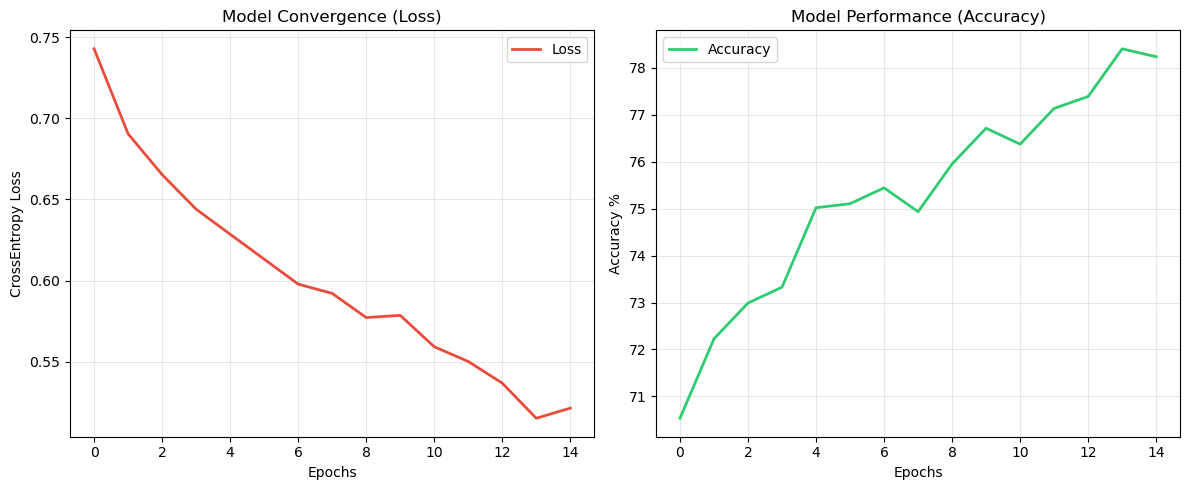


--- Generating Final Metrics ---
                     precision    recall  f1-score   support

  Negative/Conflict       0.78      0.98      0.87       852
            Neutral       1.00      0.02      0.04        46
Positive/High Alert       0.85      0.34      0.48       283

           accuracy                           0.79      1181
          macro avg       0.88      0.45      0.47      1181
       weighted avg       0.81      0.79      0.75      1181



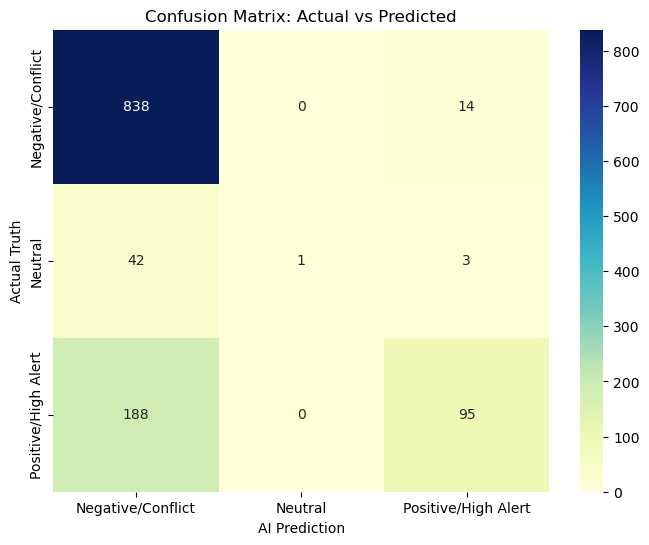

In [18]:
# Metrics

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# --- 1. PLOT TRAINING CURVES ---
# Assumes 'history' or 'train_losses' was updated in Cell 4
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss', color='#e74c3c', lw=2)
plt.title('Model Convergence (Loss)')
plt.xlabel('Epochs')
plt.ylabel('CrossEntropy Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Accuracy', color='#2ecc71', lw=2)
plt.title('Model Performance (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. FINAL METRICS (Precision, Recall, F1) ---
model.eval()
y_true = []
y_pred = []

print("\n--- Generating Final Metrics ---")
with torch.no_grad():
    for txt, img, lbl in train_loader:
        txt, img, lbl = txt.to(device), img.to(device), lbl.to(device)
        outputs = model(txt, img)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(lbl.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Map IDs back to names for the report
target_names = ['Negative/Conflict', 'Neutral', 'Positive/High Alert']
print(classification_report(y_true, y_pred, target_names=target_names))

# --- 3. CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.show()